# 2.5 Optimal Trading Strategy

This notebook implements Section 2.5 of the project by reusing the outputs and helper functions from Sections 2.1--2.4.

The objective is to build trading strategies from the synthetic alpha signals, including a synthetic overnight alpha, and then backtest these strategies with the existing backtest engine.

The implementation is designed to be consistent with the lecture notes. In the Obizhaeva--Wang model, impact satisfies

$$
dI_t = -\beta I_t dt + \lambda dQ_t.
$$

For a deterministic alpha signal, the lecture notes derive the optimal target impact state

$$
I_t^* = \frac{1}{2}\left(\alpha_t - \beta^{-1}\alpha_t'\right).
$$

Trades are then recovered from the impact dynamics:

$$
dQ_t^* = \frac{1}{\lambda}\left(\beta I_t^* dt + dI_t^*\right).
$$

In the fitted implementation from Sections 2.2--2.3, the impact state is normalized as

$$
I_{n+1}=e^{-\beta\Delta t} I_n + \lambda_{\text{hat}}\,\sigma\,\frac{\Delta Q_n}{ADV}.
$$

Therefore, after computing a target impact state from alpha, we recover trades using the discrete fitted version:

$$
\Delta Q_n
=
\frac{I_n^* - e^{-\beta\Delta t}I_{n-1}^*}
{\lambda_{\text{hat}}\sigma / ADV}.
$$

## 1. Imports and paths

This notebook assumes that the helper `.py` files and the saved results from Sections 2.1--2.4 are available in the same folder as this notebook.

In [5]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import importlib

import src.data_prep as data_prep
import src.backtest_engine as backtest_engine
import src.optimal_trading_strategies as optimal_trading_strategies

importlib.reload(data_prep)
importlib.reload(backtest_engine)
importlib.reload(optimal_trading_strategies)

from src.data_prep import *
from src.backtest_engine import *
from src.optimal_trading_strategies import *


## 2. Load outputs from previous sections

We reuse:

- Section 2.1: prepared train/test price panels and test traded-volume panels;
- Section 2.2: fitted impact model parameters;
- Section 2.3: backtest engine;
- Section 2.4: synthetic intraday alpha panel.

In [42]:

train_px_df = load_panel_csv(os.path.join(DATA_DIR, "train_px_201901_20.csv"))
test_px_df = load_panel_csv(os.path.join(DATA_DIR, "test_px_201902_20.csv"))
test_traded_volume_df = load_panel_csv(os.path.join(DATA_DIR, "test_traded_volume_201902_20.csv"))

scaling_df = load_stock_level_csv(os.path.join(DATA_DIR, "scaling_201901_20.csv"))

best_df = pd.read_csv(os.path.join(DATA_DIR, "impact_model_best_by_is_201901_train_201902_test.csv"))
stock_results_df = pd.read_csv(os.path.join(DATA_DIR, "impact_model_stock_results_201901_train_201902_test.csv"))

synthetic_alpha_df = load_panel_csv(os.path.join(DATA_DIR, "synthetic_alpha_201902_20.csv"))
synthetic_alpha_diagnostics_df = load_stock_level_csv(os.path.join(DATA_DIR, "synthetic_alpha_diagnostics_201902_20.csv"))

# Keep only common intraday columns across all objects.
test_px_df, test_traded_volume_df, synthetic_alpha_df = align_intraday_columns(
    test_px_df,
    test_traded_volume_df,
    synthetic_alpha_df,
)

print("test_px_df:", test_px_df.shape)
print("test_traded_volume_df:", test_traded_volume_df.shape)
print("synthetic_alpha_df:", synthetic_alpha_df.shape)
print("scaling_df:", scaling_df.shape)
print("best_df:", best_df.shape)
print("stock_results_df:", stock_results_df.shape)

test_px_df: (380, 2341)
test_traded_volume_df: (380, 2341)
synthetic_alpha_df: (380, 2341)
scaling_df: (20, 2)
best_df: (3, 9)
stock_results_df: (420, 25)


## 3. Reconstruct fitted model parameter tables

Section 2.2 selected one best half-life for each model type. Section 2.3 uses `get_best_model_fit_df` to extract stock-level fitted parameters for that selected half-life.

In [43]:
model_types = ["ow", "afs", "reduced_form"]

fit_dfs = {}
for model_type in model_types:
    fit_dfs[model_type] = get_best_model_fit_df(
        stock_results_df=stock_results_df,
        best_df=best_df,
        model_type=model_type,
    )

for model_type, fit_df in fit_dfs.items():
    print(model_type, fit_df.shape)
    display(fit_df[["lambda_hat", "half_life_seconds", "is_r2", "oos_r2"]].head())

ow (20, 24)


,lambda_hat,half_life_seconds,is_r2,oos_r2
stock,,,,
AAL,262.866026,1800,0.143934,0.199819
AAPL,407.392206,1800,0.231705,0.252164
ABBV,382.822089,1800,0.130716,0.131900
ABT,440.867448,1800,0.171972,0.115936
ADBE,339.189338,1800,0.123732,0.137870


afs (20, 24)


,lambda_hat,half_life_seconds,is_r2,oos_r2
stock,,,,
AAL,0.770608,300,0.151269,0.185629
AAPL,0.828313,300,0.234038,0.227081
ABBV,0.540337,300,0.102414,0.115905
ABT,0.550386,300,0.133748,0.099200
ADBE,0.573366,300,0.130973,0.123505


reduced_form (20, 24)


,lambda_hat,half_life_seconds,is_r2,oos_r2
stock,,,,
AAL,73.752339,600,0.181003,0.244088
AAPL,106.653594,600,0.281354,0.309429
ABBV,89.711831,600,0.151770,0.123431
ABT,99.691282,600,0.186580,0.098858
ADBE,87.620862,600,0.156239,0.175975


## 4. Synthetic overnight alpha

The lecture notes suggest comparing execution slippage to the overnight return

$$
\frac{P_{\text{next open}} - P_{\text{close}}}{P_{\text{close}}}.
$$

For each stock-date in the test set, we define a synthetic overnight alpha as the next open return. This is a look-ahead construction, consistent with the synthetic alpha design in Section 2.4.

The overnight alpha is constant across the intraday grid for a given stock-day:

$$
\alpha^{ON}_{d,t}=A_{ON}\frac{P_{d+1,\text{open}}-P_{d,\text{close}}}{P_{d,\text{close}}}.
$$

In [44]:

overnight_alpha_level = 1.0
overnight_alpha_df, overnight_alpha_series = make_next_open_overnight_alpha_panel(
    test_px_df=test_px_df,
    overnight_alpha_level=overnight_alpha_level,
)

print("overnight_alpha_df:", overnight_alpha_df.shape)
display(overnight_alpha_series.groupby(level="stock").describe().head())

overnight_alpha_df: (380, 2341)


,count,mean,std,min,25%,50%,75%,max
stock,,,,,,,,
AAL,19.0,-0.000057,0.005563,-0.011987,-0.004036,0.002076,0.002927,0.010862
AAPL,19.0,0.000391,0.005544,-0.011792,-0.002960,0.001492,0.003796,0.010524
ABBV,19.0,0.000005,0.004404,-0.008227,-0.003378,-0.000693,0.002885,0.009753
ABT,19.0,-0.000888,0.005272,-0.009933,-0.004784,-0.001334,0.003339,0.007709
ADBE,19.0,0.000430,0.006124,-0.010853,-0.003250,-0.000213,0.005226,0.011708


## 5. Alpha scenarios

We construct four alpha scenarios:

1. **No alpha**: zero signal. Under the unconstrained OW alpha-trading problem, this produces no trades, so it is used only as a conceptual benchmark.
2. **Overnight alpha only**: uses only the next-open overnight signal.
3. **Intraday alpha only**: uses the synthetic intraday alpha from Section 2.4.
4. **Combined alpha**: uses both overnight and intraday alpha.

The project instruction specifically asks us to simulate strategies with and without intraday alpha. These correspond to scenarios 2 and 4.

For the backtest, we exclude `no_alpha` because it has zero traded notional and therefore undefined bps metrics.

In [45]:
alpha_scenarios = {
    "no_alpha": synthetic_alpha_df * 0.0,
    "overnight_only": overnight_alpha_df,
    "intraday_only": synthetic_alpha_df,
    "combined": synthetic_alpha_df + overnight_alpha_df,
}

for name, alpha_df in alpha_scenarios.items():
    print(name, alpha_df.shape, "mean abs alpha:", alpha_df.abs().stack().mean())

no_alpha (380, 2341) mean abs alpha: 0.0
overnight_only (380, 2341) mean abs alpha: 0.005519493643351232
intraday_only (380, 2341) mean abs alpha: 0.002192583807217555
combined (380, 2341) mean abs alpha: 0.006100073756288823


## 6. OW optimal strategy from target impact

The lecture notes formulate the solution in impact space:

$$
I_t^* = \frac{1}{2}\left(\alpha_t - \beta^{-1}\alpha_t'\right).
$$

Because the previous notebooks fit impact in return units as

$$
I_{n+1}=e^{-\beta\Delta t} I_n + \lambda_{\text{hat}}\sigma\frac{\Delta Q_n}{ADV},
$$

we recover trades from

$$
\Delta Q_n
=
\frac{I_n^* - e^{-\beta\Delta t}I_{n-1}^*}
{\lambda_{\text{hat}}\sigma/ADV}.
$$

The optional normalization below keeps total absolute daily traded volume comparable across alpha scenarios. This is useful for backtest comparison because the analytical OW alpha strategy is unconstrained and otherwise chooses its own trade size from the alpha magnitude.

## 7. Generate OW optimal trades for backtest alpha scenarios

We generate the OW optimal trading shape using the fitted OW parameters from Section 2.2. We normalize total absolute daily traded volume to 20% ADV to keep the backtests comparable with the TWAP benchmarks from Section 2.3.

We backtest `overnight_only`, `intraday_only`, and `combined`. The zero-alpha case is not included because the unconstrained alpha strategy simply does not trade.

In [46]:
dt_seconds = 10
target_participation = 0.20

ow_fit_df = fit_dfs["ow"]

strategy_trade_dfs = {}
target_impact_dfs = {}
alpha_prime_dfs = {}

backtest_alpha_scenario_names = ["overnight_only", "intraday_only", "combined"]

for scenario_name in backtest_alpha_scenario_names:
    alpha_df = alpha_scenarios[scenario_name]
    trades_df, target_impact_df, alpha_prime_df = make_ow_optimal_trade_df(
        alpha_df=alpha_df,
        test_px_df=test_px_df,
        scaling_df=scaling_df,
        fit_df=ow_fit_df,
        dt_seconds=dt_seconds,
        normalize_abs_volume=True,
        target_participation=target_participation,
    )

    strategy_trade_dfs[scenario_name] = trades_df
    target_impact_dfs[scenario_name] = target_impact_df
    alpha_prime_dfs[scenario_name] = alpha_prime_df

    print(scenario_name)
    print("  total abs traded:", trades_df.abs().sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())
    print("  net traded:", trades_df.sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())

overnight_only
  total abs traded: {'mean': 199417.7566917294, '50%': 82873.19047619049, 'min': 0.0, 'max': 1848185.8476190488}
  net traded: {'mean': 4880.1710776942355, '50%': 0.0, 'min': -1848185.8476190488, 'max': 1848185.8476190488}
intraday_only
  total abs traded: {'mean': 210496.52095238105, '50%': 86099.19523809524, 'min': 51435.323809523805, 'max': 1848185.8476190486}
  net traded: {'mean': 0.9114108689710201, '50%': 1.192103511257038, 'min': -191.45238344203176, 'max': 207.67735181780085}
combined
  total abs traded: {'mean': 210496.52095238105, '50%': 86099.19523809524, 'min': 51435.323809523805, 'max': 1848185.8476190486}
  net traded: {'mean': 7.569578179854877, '50%': -0.06980837553562225, 'min': -1949.8290537995, 'max': 2552.7667363078117}


## 8. TWAP benchmark from Section 2.3

We also reuse the round-trip TWAP benchmark from the backtest engine. This is not alpha-based, but it is useful as a sanity-check benchmark.

In [47]:
twap_round_trip_trades_df = make_round_trip_twap_trade_df(
    test_px_df=test_px_df,
    scaling_df=scaling_df,
    participation_rate=target_participation,
)

strategy_trade_dfs["round_trip_twap"] = twap_round_trip_trades_df

print("round_trip_twap")
print("  total abs traded:", twap_round_trip_trades_df.abs().sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())
print("  net traded:", twap_round_trip_trades_df.sum(axis=1).describe()[["mean", "50%", "min", "max"]].to_dict())

round_trip_twap
  total abs traded: {'mean': 420993.0419047621, '50%': 172198.39047619049, 'min': 102870.64761904764, 'max': 3696371.6952380966}
  net traded: {'mean': 1.8553691916167735e-11, '50%': 0.0, 'min': -2.9103830456733704e-11, 'max': 4.656612873077393e-10}


## 9. Backtest strategies using the Section 2.3 engine

The previous section's backtest engine first removes public market impact, then simulates our strategy trades under a fitted impact model.

We first backtest the strategies under the fitted OW model. Then, optionally, we can also run the same trade schedules under the AFS and reduced-form fitted models to check model robustness.

In [48]:



ow_strategy_backtests_df = run_strategy_backtests_for_model(
    strategy_trade_dfs=strategy_trade_dfs,
    model_type="ow",
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=dt_seconds,
)

summary_cols = [
    "pnl_bps",
    "impact_cost_bps",
    "max_abs_impact",
    "total_abs_traded",
    "net_traded",
]

ow_summary = (
    ow_strategy_backtests_df
    .groupby("strategy")[summary_cols]
    .agg(["mean", "median", "std"])
)

display(ow_summary)

pnl_bps                       impact_cost_bps             \
                      mean     median        std            mean     median   
strategy                                                                      
combined         -2.204541  -1.968702   1.006279        0.100361   0.092891   
intraday_only    -2.204652  -1.960365   1.006517        0.100355   0.092881   
overnight_only  -25.199485 -21.113527  49.457584       24.490439  22.613175   
round_trip_twap -33.731690 -30.852410  30.662513       36.898277  34.064341   

                           max_abs_impact                      \
                       std           mean    median       std   
strategy                                                        
combined          0.038026       0.015598  0.005286  0.035514   
intraday_only     0.038025       0.015605  0.005299  0.035521   
overnight_only    9.726727       0.891029  0.242758  2.374416   
round_trip_twap  14.648919       1.137729  0.350235  2.938526   

                total_abs_traded                                  net_traded  \
                            mean         median            std          mean   
strategy                                                                       
combined           210496.520952   86099.195238  395491.992969  7.569578e+00   
intraday_only      210496.520952   86099.195238  395491.992969  9.114109e-01   
overnight_only     199417.756692   82873.190476  387810.181297  4.880171e+03   
round_trip_twap    420993.041905  172198.390476  790983.985938  1.855369e-11   

                                         
                   median           std  
strategy                                 
combined        -0.069808  2.334819e+02  
intraday_only    1.192104  2.743128e+01  
overnight_only   0.000000  4.361711e+05  
round_trip_twap  0.000000  1.037129e-10

## 10. Plot strategy comparison

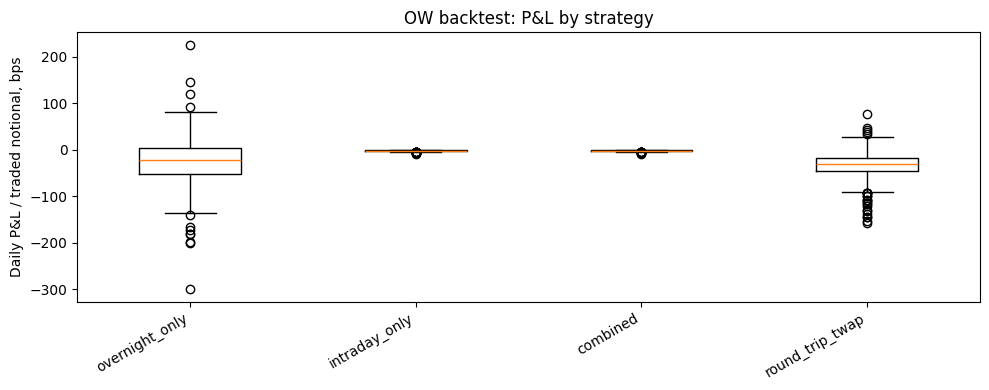

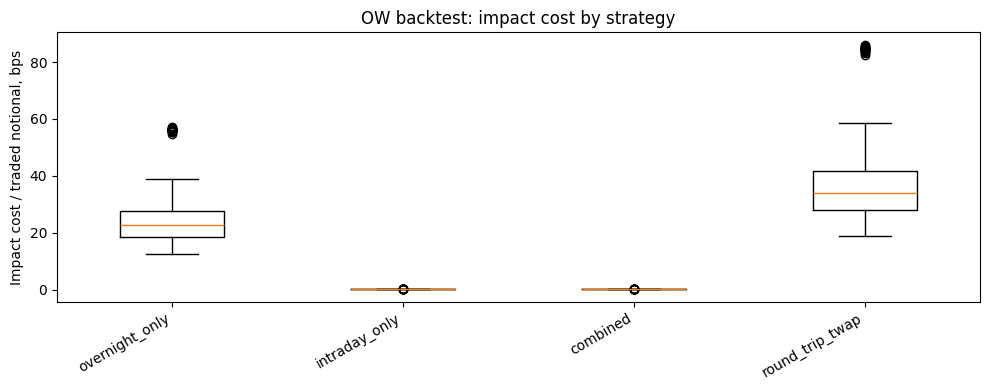

In [49]:
def plot_strategy_boxplot(backtest_df, metric, title, ylabel):
    strategies = backtest_df["strategy"].unique()
    data = [
        backtest_df.loc[backtest_df["strategy"] == s, metric].dropna()
        for s in strategies
    ]

    plt.figure(figsize=(10, 4))
    plt.boxplot(data, tick_labels=strategies)
    plt.xticks(rotation=30, ha="right")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


plot_strategy_boxplot(
    ow_strategy_backtests_df,
    metric="pnl_bps",
    title="OW backtest: P&L by strategy",
    ylabel="Daily P&L / traded notional, bps",
)

plot_strategy_boxplot(
    ow_strategy_backtests_df,
    metric="impact_cost_bps",
    title="OW backtest: impact cost by strategy",
    ylabel="Impact cost / traded notional, bps",
)

## 11. One-stock-day diagnostic

The plots below show how the alpha signal maps into target impact and trades for one stock-day.

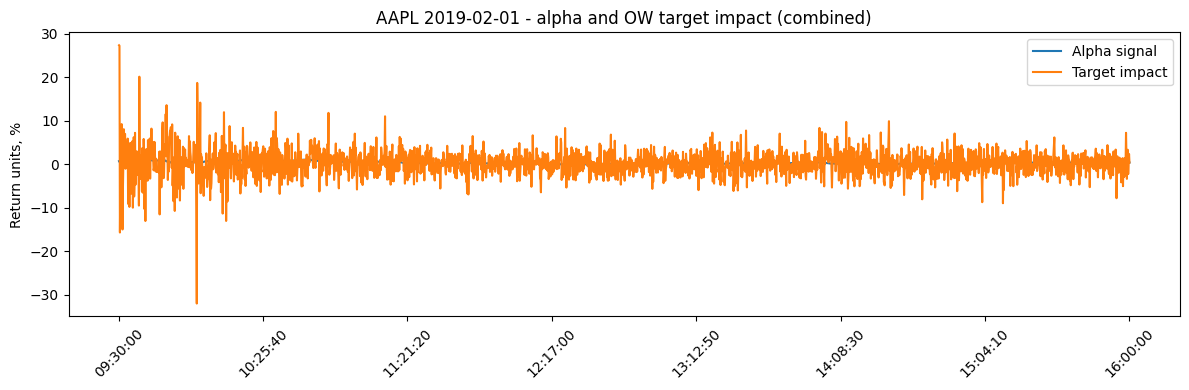

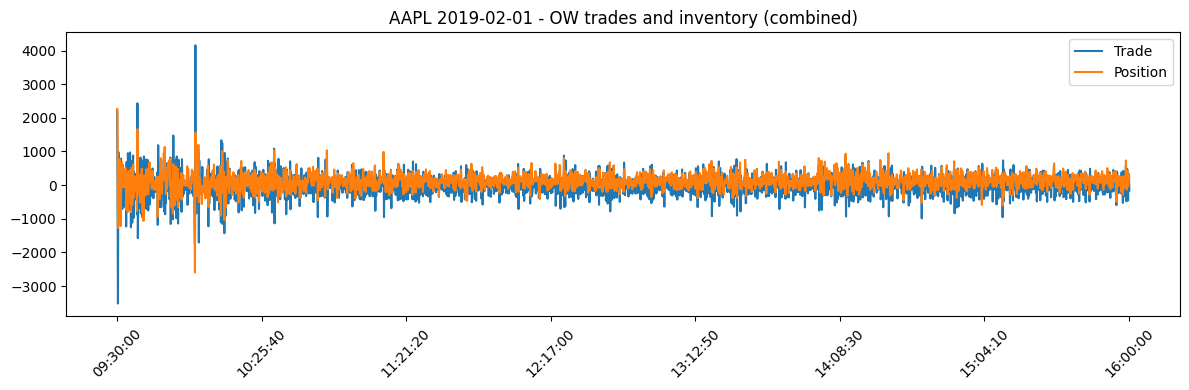

In [50]:
stock = "AAPL"
# Pick the first available AAPL test date if the chosen stock exists.
if stock in test_px_df.index.get_level_values("stock"):
    date = test_px_df.loc[stock].index[0]
else:
    stock, date = test_px_df.index[0]

scenario_name = "combined"

alpha_one = alpha_scenarios[scenario_name].loc[(stock, date)]
I_star_one = target_impact_dfs[scenario_name].loc[(stock, date)]
trades_one = strategy_trade_dfs[scenario_name].loc[(stock, date)]
position_one = trades_one.cumsum()

x = np.arange(len(alpha_one))
tick_positions = np.linspace(0, len(alpha_one) - 1, 8, dtype=int)
tick_labels = alpha_one.index[tick_positions]

plt.figure(figsize=(12, 4))
plt.plot(x, 100 * alpha_one.values, label="Alpha signal")
plt.plot(x, 100 * I_star_one.values, label="Target impact")
plt.xticks(tick_positions, tick_labels, rotation=45)
plt.ylabel("Return units, %")
plt.title(f"{stock} {date} - alpha and OW target impact ({scenario_name})")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(x, trades_one.values, label="Trade")
plt.plot(x, position_one.values, label="Position")
plt.xticks(tick_positions, tick_labels, rotation=45)
plt.title(f"{stock} {date} - OW trades and inventory ({scenario_name})")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
def compute_pre_post_execution_impact_one_day(
    my_trades,
    ADV,
    sigma,
    half_life_seconds,
    model_type="ow",
    dt_seconds=10,
    eps=1e-12,
):
    """
    Compute pre-trade impact, post-trade impact, and execution impact.

    The execution impact is approximated by the midpoint between
    pre-trade and post-trade impact, consistent with the OW flat-book
    lecture intuition.
    """

    my_trades = my_trades.fillna(0.0).astype(float)

    beta = np.log(2) / half_life_seconds
    decay = np.exp(-beta * dt_seconds)

    pre_features = []
    post_features = []
    exec_features = []

    if model_type == "ow":
        I_prev = 0.0

        for q in my_trades:
            I_pre = decay * I_prev
            input_term = sigma * q / ADV
            I_post = I_pre + input_term

            I_exec = 0.5 * (I_pre + I_post)

            pre_features.append(I_pre)
            post_features.append(I_post)
            exec_features.append(I_exec)

            I_prev = I_post

    elif model_type == "sqrt_propagator":
        I_prev = 0.0

        for q in my_trades:
            I_pre = decay * I_prev

            q_scaled = q / ADV
            input_term = sigma * np.sign(q_scaled) * np.sqrt(abs(q_scaled))

            I_post = I_pre + input_term
            I_exec = 0.5 * (I_pre + I_post)

            pre_features.append(I_pre)
            post_features.append(I_post)
            exec_features.append(I_exec)

            I_prev = I_post

    elif model_type == "afs":
        J_prev = 0.0

        for q in my_trades:
            J_pre = decay * J_prev
            J_post = J_pre + sigma * q / ADV

            I_pre = np.sign(J_pre) * np.sqrt(abs(J_pre))
            I_post = np.sign(J_post) * np.sqrt(abs(J_post))

            I_exec = 0.5 * (I_pre + I_post)

            pre_features.append(I_pre)
            post_features.append(I_post)
            exec_features.append(I_exec)

            J_prev = J_post

    elif model_type == "reduced_form":
        I_prev = 0.0
        v_prev = 0.0

        for q in my_trades:
            I_pre = decay * I_prev
            v_pre = decay * v_prev

            v_post = max(v_pre + abs(q), eps)

            input_term = sigma * q / np.sqrt(ADV * v_post)

            I_post = I_pre + input_term
            I_exec = 0.5 * (I_pre + I_post)

            pre_features.append(I_pre)
            post_features.append(I_post)
            exec_features.append(I_exec)

            I_prev = I_post
            v_prev = v_post

    else:
        raise ValueError("Unknown model_type.")

    return pd.DataFrame(
        {
            "pre_impact_feature": pre_features,
            "post_impact_feature": post_features,
            "execution_impact_feature": exec_features,
        },
        index=my_trades.index,
    )

In [65]:
def simulate_one_stock_day_with_naive_and_realistic_pnl(
    stock,
    date,
    strategy_name,
    model_type,
    strategy_trade_dfs,
    test_px_df,
    test_traded_volume_df,
    scaling_df,
    fit_dfs,
    dt_seconds=10,
):
    fit_df = fit_dfs[model_type]

    raw_prices = test_px_df.loc[(stock, date)].astype(float)
    public_trades = test_traded_volume_df.loc[(stock, date)].astype(float)
    my_trades = strategy_trade_dfs[strategy_name].loc[(stock, date)].astype(float)

    lambda_hat = float(fit_df.loc[stock, "lambda_hat"])
    half_life_seconds = float(fit_df.loc[stock, "half_life_seconds"])

    ADV = float(scaling_df.loc[stock, "ADV"])
    sigma = float(scaling_df.loc[stock, "sigma"])

    # Impact-free price S_t
    impact_free_price = make_impact_adjusted_prices(
        prices=raw_prices,
        public_trades=public_trades,
        lambda_hat=lambda_hat,
        ADV=ADV,
        sigma=sigma,
        half_life_seconds=half_life_seconds,
        model_type=model_type,
        dt_seconds=dt_seconds,
    )

    impact_df = compute_pre_post_execution_impact_one_day(
        my_trades=my_trades,
        ADV=ADV,
        sigma=sigma,
        half_life_seconds=half_life_seconds,
        model_type=model_type,
        dt_seconds=dt_seconds,
    )

    impact_df = lambda_hat * impact_df

    pre_impact_in_price = impact_free_price.iloc[0] * impact_df["pre_impact_feature"]
    post_impact_in_price = impact_free_price.iloc[0] * impact_df["post_impact_feature"]
    execution_impact_in_price = impact_free_price.iloc[0] * impact_df["execution_impact_feature"]

    # Observed post-trade impacted price P_t
    impact_resultant_price = impact_free_price + post_impact_in_price

    # Traded/VWAP price through the book
    execution_price = impact_free_price + execution_impact_in_price

    position = my_trades.cumsum()
    cash = -(my_trades * execution_price).cumsum()

    # Accounting / naive PnL: mark at observed impacted price
    naive_pnl = cash + position * impact_resultant_price

    # Fundamental / realistic PnL: mark at impact-free price
    realistic_pnl = cash + position * impact_free_price

    path_df = pd.DataFrame(
        {
            "raw_mid_price": raw_prices,
            "impact_free_price": impact_free_price,
            "trade": my_trades,
            "position": position,
            "pre_impact_in_price": pre_impact_in_price,
            "post_impact_in_price": post_impact_in_price,
            "execution_impact_in_price": execution_impact_in_price,
            "impact_in_price": post_impact_in_price,
            "impact_resultant_price": impact_resultant_price,
            "execution_price": execution_price,
            "cash": cash,
            "naive_pnl": naive_pnl,
            "realistic_pnl": realistic_pnl,
            "footprint_pnl": naive_pnl - realistic_pnl,
        }
    )

    summary = {
        "stock": stock,
        "date": date,
        "strategy": strategy_name,
        "model_type": model_type,
        "lambda_hat": lambda_hat,
        "half_life_seconds": half_life_seconds,
        "ADV": ADV,
        "sigma": sigma,
        "final_naive_pnl": naive_pnl.iloc[-1],
        "final_realistic_pnl": realistic_pnl.iloc[-1],
        "final_footprint_pnl": path_df["footprint_pnl"].iloc[-1],
        "impact_cost": (my_trades * execution_impact_in_price).sum(),
        "total_abs_traded": my_trades.abs().sum(),
        "net_traded": my_trades.sum(),
        "max_abs_impact": post_impact_in_price.abs().max(),
    }

    return path_df, summary

In [71]:
def plot_lecture_style_strategy_diagnostics(
    path_df,
    stock,
    date,
    strategy_name,
    model_type,
    sample_every=10,
):
    """
    Lecture-style plots:
    1. impact-free price vs impact-resultant price,
    2. cumulative impact,
    3. trade size,
    4. naive/accounting PnL vs realistic/fundamental PnL.
    """

    plot_df = path_df.iloc[::sample_every].copy()

    x = np.arange(len(plot_df))
    tick_positions = np.linspace(0, len(plot_df) - 1, 8, dtype=int)
    tick_labels = plot_df.index[tick_positions]

    # 1. Price plot
    plt.figure(figsize=(12, 4))

    plt.plot(
        x,
        plot_df["impact_free_price"].values,
        label="Impact-free price",
    )

    plt.plot(
        x,
        plot_df["impact_resultant_price"].values,
        label="Impact-resultant price",
    )

    plt.xticks(tick_positions, tick_labels, rotation=45)
    plt.title(
        f"{stock} {date} - {strategy_name} under {model_type}: "
        "impact-free vs impact-resultant price"
    )
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # 2. Cumulative impact
    plt.figure(figsize=(12, 4))

    plt.plot(
        x,
        100 * plot_df["impact_in_price"].values,
        label="Cumulative impact",
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xticks(tick_positions, tick_labels, rotation=45)
    plt.title(
        f"{stock} {date} - {strategy_name} under {model_type}: cumulative impact"
    )
    plt.xlabel("Time")
    plt.ylabel("Impact, cents")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # 3. Trade size
    plt.figure(figsize=(12, 4))

    plt.bar(
        x,
        plot_df["trade"].values,
        width=1.0,
        label="Trade size",
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xticks(tick_positions, tick_labels, rotation=45)
    plt.title(
        f"{stock} {date} - {strategy_name} under {model_type}: trade size"
    )
    plt.xlabel("Time")
    plt.ylabel("Shares")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    # 4. Naive vs realistic PnL
    plt.figure(figsize=(12, 4))

    plt.plot(
        x,
        plot_df["naive_pnl"].values,
        label="Naive/accounting PnL",
    )

    plt.plot(
        x,
        plot_df["realistic_pnl"].values,
        label="Realistic/fundamental PnL",
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xticks(tick_positions, tick_labels, rotation=45)
    plt.title(
        f"{stock} {date} - {strategy_name} under {model_type}: PnL comparison"
    )
    plt.xlabel("Time")
    plt.ylabel("PnL")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

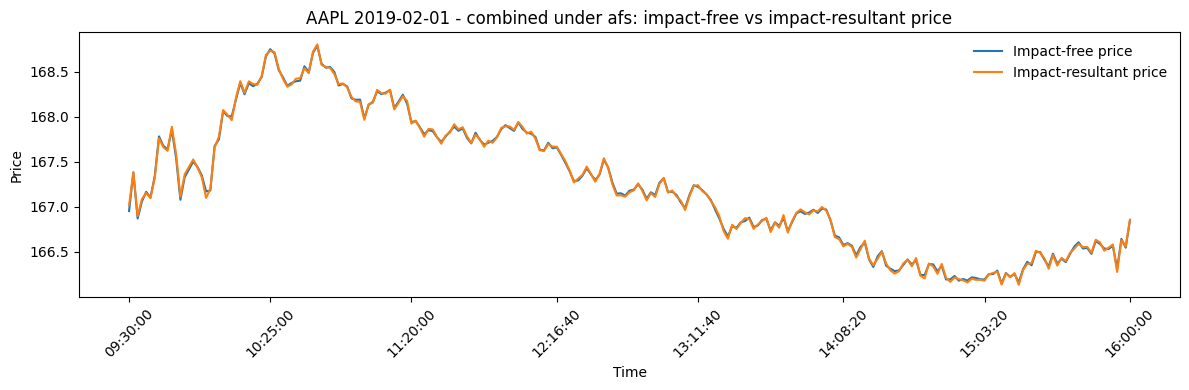

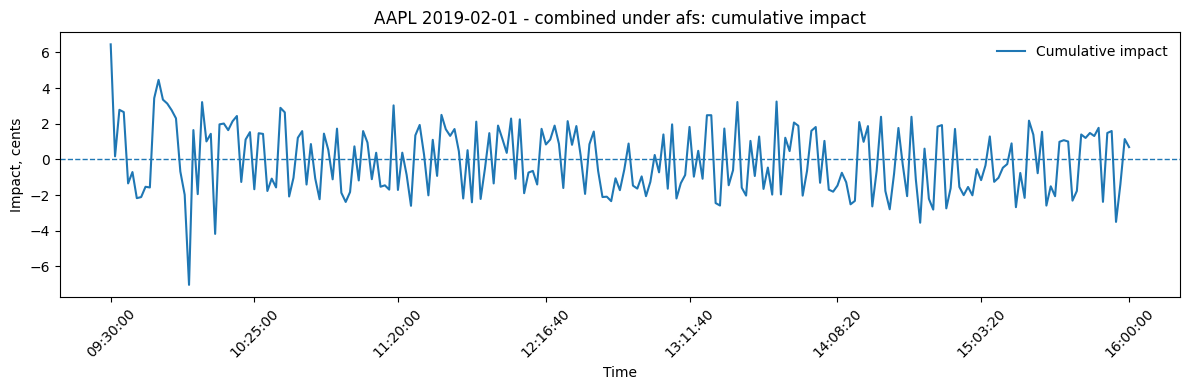

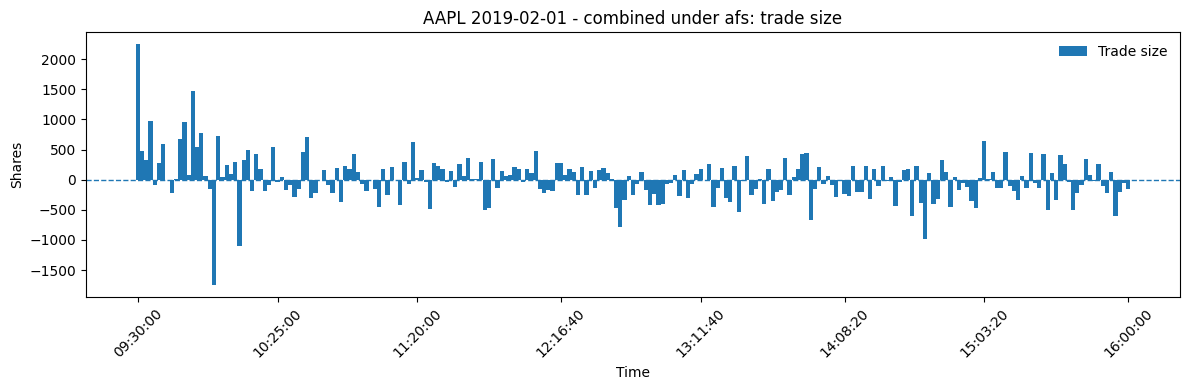

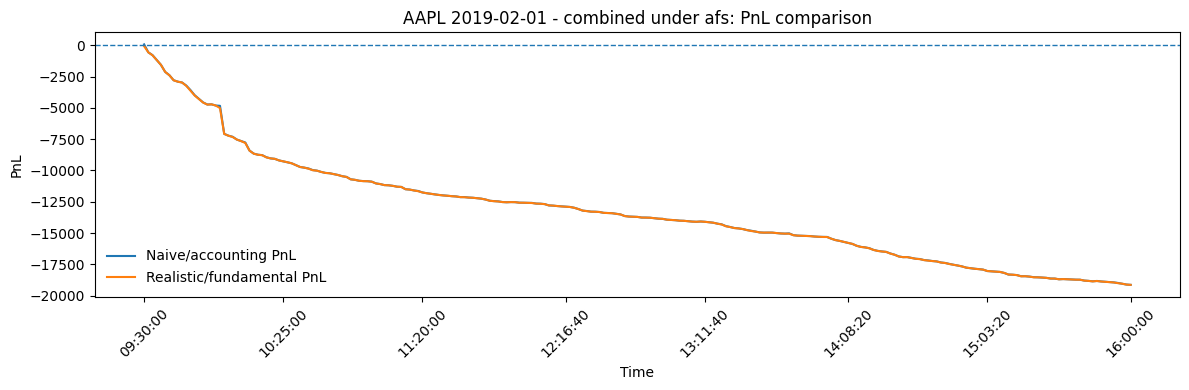

In [72]:
path_df, summary = simulate_one_stock_day_with_naive_and_realistic_pnl(
    stock="AAPL",
    date="2019-02-01",
    strategy_name="combined",
    model_type="afs",
    strategy_trade_dfs=strategy_trade_dfs,
    test_px_df=test_px_df,
    test_traded_volume_df=test_traded_volume_df,
    scaling_df=scaling_df,
    fit_dfs=fit_dfs,
    dt_seconds=10,
)

plot_lecture_style_strategy_diagnostics(
    path_df=path_df,
    stock="AAPL",
    date="2019-02-01",
    strategy_name="combined",
    model_type="afs",
    sample_every=10,
)

## 12. Optional robustness: backtest same trade schedules under all fitted models

The OW formula produces the trade schedules. We can then use the existing backtest engine to evaluate these schedules under each fitted impact model from Section 2.2.

In [57]:
run_all_model_robustness = True

if run_all_model_robustness:
    all_model_results = []

    for model_type in model_types:
        model_bt = run_strategy_backtests_for_model(
            strategy_trade_dfs=strategy_trade_dfs,
            model_type=model_type,
            test_px_df=test_px_df,
            test_traded_volume_df=test_traded_volume_df,
            scaling_df=scaling_df,
            fit_dfs=fit_dfs,
            dt_seconds=dt_seconds,
        )
        all_model_results.append(model_bt)

    all_model_strategy_backtests_df = pd.concat(all_model_results, ignore_index=True)

    display(
        all_model_strategy_backtests_df
        .groupby(["backtest_model", "strategy"])[["pnl_bps", "impact_cost_bps"]]
        .agg(["mean", "median", "std"])
    )
else:
    print("Set run_all_model_robustness=True to run robustness backtests under AFS and reduced-form models.")

pnl_bps                        \
                                     mean     median        std   
backtest_model strategy                                           
afs            combined         -2.961082  -2.655838   1.228877   
               intraday_only    -2.962534  -2.667837   1.229486   
               overnight_only   -8.744954  -7.683328  45.705777   
               round_trip_twap  -6.482756  -3.905368  25.603310   
ow             combined         -2.204541  -1.968702   1.006279   
               intraday_only    -2.204652  -1.960365   1.006517   
               overnight_only  -25.199485 -21.113527  49.457584   
               round_trip_twap -33.731690 -30.852410  30.662513   
reduced_form   combined         -2.345679  -2.079602   1.042262   
               intraday_only    -2.346040  -2.080789   1.042445   
               overnight_only  -30.557768 -26.189035  45.229212   
               round_trip_twap -31.652129 -28.605851  28.599779   

                               impact_cost_bps                        
                                          mean     median        std  
backtest_model strategy                                               
afs            combined               0.852210   0.726098   0.414697  
               intraday_only          0.852300   0.727005   0.414711  
               overnight_only         8.648165   7.405131   4.237013  
               round_trip_twap        9.902546   8.478048   4.848980  
ow             combined               0.100361   0.092891   0.038026  
               intraday_only          0.100355   0.092881   0.038025  
               overnight_only        24.490439  22.613175   9.726727  
               round_trip_twap       36.898277  34.064341  14.648919  
reduced_form   combined               0.300637   0.283538   0.102090  
               intraday_only          0.300621   0.283600   0.102104  
               overnight_only        28.883220  27.791802  10.270163  
               round_trip_twap       35.038169  33.708311  12.455693

## 13. Save Section 2.5 outputs

In [52]:
OUTPUT_DIR = DATA_DIR

# Save trade panels.
for strategy_name, trades_df in strategy_trade_dfs.items():
    out = trades_df.reset_index()
    out.to_csv(
        os.path.join(OUTPUT_DIR, f"strategy_trades_{strategy_name}_201902_20.csv"),
        index=False,
    )

# Save main OW backtest comparison.
ow_strategy_backtests_df.to_csv(
    os.path.join(OUTPUT_DIR, "backtest_ow_optimal_alpha_strategies_201902_20.csv"),
    index=False,
)

# Save compact summary.
ow_summary.to_csv(
    os.path.join(OUTPUT_DIR, "backtest_ow_optimal_alpha_strategy_summary_201902_20.csv")
)

print("Saved Section 2.5 outputs.")

Saved Section 2.5 outputs.


## Interpretation

This section extends the baseline backtest in three ways.

First, it uses the synthetic intraday alpha from Section 2.4 as the directional input to the trading strategy.

Second, it adds a synthetic overnight alpha based on the next-open return. This corresponds to a long-horizon directional signal that is constant throughout the intraday trading window.

Third, it converts alpha into trades using the OW optimal strategy from the lecture notes. The strategy is expressed through a target impact state rather than through a direct heuristic schedule such as TWAP or VWAP.

The central economic interpretation is:

- stronger alpha increases the target impact state;
- faster alpha decay increases trading urgency through the alpha derivative term;
- overnight alpha generates a persistent directional bias;
- intraday alpha dynamically changes the trading trajectory during the day;
- the fitted impact model determines how much volume is required to reach the target impact.

The most important comparison for the project is between:

- `overnight_only`: synthetic overnight alpha without intraday alpha;
- `combined`: synthetic overnight alpha with intraday alpha.

This directly answers the instruction to simulate trading strategies with and without the intraday alpha.